In [ ]:
This project uses Markov Chains to model how Shohei Ohtani and Aaron Judge influence run production compared to the league median. 

In [1]:
pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [25]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:

# Create a database file on disk
conn = duckdb.connect('example.db')
# Enable remote access
conn.sql("INSTALL httpfs")
conn.sql("LOAD httpfs")
# This database file points to files totaling multiple GBs,
# but it's only about 300KB itself. The `ATTACH` command
# gives us access to views that sit on top of remote Parquet files.
try:
  conn.sql("ATTACH 'https://data.baseball.computer/dbt/bc_remote.db' (READ_ONLY)")
except duckdb.BinderException:
  # This command will fail if you run it more than once because it already exists,
  # in which case we don't need to do anything
  pass

conn.sql("USE bc_remote")
conn.sql("USE main_models")

In [139]:
# getting Aaron Judge stats and numbers
Aaron_J = pd.DataFrame = conn.sql("SELECT player_id FROM people WHERE first_name = 'Aaron' AND last_name = 'Judge'").df() # retrieve Aaron Judge Player ID 
#Aaron_J

Aaron_J_stats = pd.DataFrame = conn.sql("SELECT at_bats, singles, doubles, triples, home_runs, batting_outs, strikeouts FROM metrics_player_season_league_offense WHERE player_id = 'judga001'"
 ).df()
# testing dataframe
Aaron_J_stats





,at_bats,singles,doubles,triples,home_runs,batting_outs,strikeouts
0,84,9,2,0,4,72,42
1,367,45,16,0,37,277,130
2,550,95,24,0,39,413,158
3,378,57,18,1,27,287,141
4,413,66,22,0,27,313,152
5,542,75,24,3,52,407,208
6,570,87,28,0,62,412,175
7,101,14,3,0,9,80,32


In [95]:
# I am going to use total career numbers for both players
Aaron_J_amount_of_at_bats = Aaron_J_stats["at_bats"].sum()
Aaron_J_amount_of_singles = Aaron_J_stats["singles"].sum()
Aaron_J_amount_of_doubles = Aaron_J_stats["doubles"].sum()
Aaron_J_amount_of_triples = Aaron_J_stats["triples"].sum()
Aaron_J_amount_of_home_runs = Aaron_J_stats["home_runs"].sum()
Aaron_J_amount_of_batting_outs = Aaron_J_stats["batting_outs"].sum()



2261

In [137]:
# getting Shohei Ohtani stats
Shohei_O = pd.DataFrame = conn.sql("SELECT player_id FROM people WHERE first_name = 'Shohei' AND last_name = 'Ohtani'").df() # retrieve Aaron Judge Player ID
#Shohei_O # retrieving Shohei Ohtani player_id
Shohei_O_stats = pd.DataFrame = conn.sql("SELECT at_bats, singles, doubles, triples, home_runs, batting_outs, strikeouts FROM metrics_player_season_league_offense WHERE player_id = 'ohtas001'"
 ).df()
Shohei_O_stats
# batting out accounts for out.

,at_bats,singles,doubles,triples,home_runs,batting_outs,strikeouts
0,537,58,26,8,46,408,189
1,497,73,26,8,44,358,143
2,586,90,30,6,34,435,161
3,326,48,21,2,22,236,102
4,384,67,20,5,18,284,110
5,153,16,6,0,7,127,50


In [101]:
Shohei_O_amount_of_at_bats = Shohei_O_stats["at_bats"].sum()
Shohei_O_amount_of_singles = Shohei_O_stats["singles"].sum()
Shohei_O_amount_of_doubles = Shohei_O_stats["doubles"].sum()
Shohei_O_amount_of_triples = Shohei_O_stats["triples"].sum()
Shohei_O_amount_of_home_runs = Shohei_O_stats["home_runs"].sum()
Shohei_O_amount_of_batting_outs = Shohei_O_stats["batting_outs"].sum()

1848

In [181]:
# getting median MLB player stats
# I generated a rough estimate using ChatGPT.
# It's description: These figures are general estimates, synthesized to reflect a player who isn't a Hall of Famer but is better than a short-term bench player. This "median MLB player" likely represents someone who was a regular starter for several seasons or had a mix of starting and bench roles over a decade-long career.

median_player_singles = 750
median_player_doubles = 150
median_player_triples = 20
median_player_home_runs = 100
median_player_batting_outs = 3000




In [ ]:

# for simplicity use probability for singles, doubles, triples, HR, based on any bat. # exclude walks and hit by pitches b/c they don't result in ball in play


# to find probability of an outcome use conditional probability and the following equations for each outcome, - This approach focuses only on plate appearances that result in batted-ball outcomes
# P(Single) = Singles/ (Singles + Doubles + Triples + HomeRuns + Outs) 
# P(Double) = Doubles/ (Singles + Doubles + Triples + HomeRuns + Outs) 
# P(Triple) = Triples/ (Singles + Doubles + Triples + HomeRuns + Outs) 
# P(HR) = HomeRuns/(Singles + Doubles + Triples + HomeRuns + Outs)   
# P(Out) = Outs/(Singles + Doubles + Triples + HomeRuns + Outs) 

In [141]:
# calculating probabiltiy for Aaron Judge 
# round to four decimal places

Aaron_J_prob_of_single = Aaron_J_amount_of_singles/(Aaron_J_amount_of_singles + Aaron_J_amount_of_doubles + Aaron_J_amount_of_triples + Aaron_J_amount_of_home_runs+ Aaron_J_amount_of_batting_outs)
#Aaron_J_prob_of_single.round(4)

Aaron_J_prob_of_double = Aaron_J_amount_of_doubles/(Aaron_J_amount_of_singles + Aaron_J_amount_of_doubles + Aaron_J_amount_of_triples + Aaron_J_amount_of_home_runs+ Aaron_J_amount_of_batting_outs)
#Aaron_J_prob_of_double.round(4)

Aaron_J_prob_of_triple = Aaron_J_amount_of_triples/(Aaron_J_amount_of_singles + Aaron_J_amount_of_doubles + Aaron_J_amount_of_triples + Aaron_J_amount_of_home_runs+ Aaron_J_amount_of_batting_outs)

#Aaron_J_prob_of_triple.round(4)

Aaron_J_prob_of_homerun = Aaron_J_amount_of_home_runs/(Aaron_J_amount_of_singles + Aaron_J_amount_of_doubles + Aaron_J_amount_of_triples + Aaron_J_amount_of_home_runs+ Aaron_J_amount_of_batting_outs)

#Aaron_J_prob_of_homerun.round(4)

Aaron_J_prob_of_batting_out = Aaron_J_amount_of_batting_outs/(Aaron_J_amount_of_singles + Aaron_J_amount_of_doubles + Aaron_J_amount_of_triples + Aaron_J_amount_of_home_runs+ Aaron_J_amount_of_batting_outs)

# testing that it adds to one
sum_to_1 = Aaron_J_prob_of_batting_out.round(4) + Aaron_J_prob_of_homerun.round(4) + Aaron_J_prob_of_triple.round(4) + Aaron_J_prob_of_double.round(4) + Aaron_J_prob_of_single.round(4)

print(sum_to_1)



1.0


In [153]:
# calculating probabiltiy for Shohei Ohtani 
Shohei_O_prob_of_single = Shohei_O_amount_of_singles/(Shohei_O_amount_of_singles + Shohei_O_amount_of_doubles + Shohei_O_amount_of_triples + Shohei_O_amount_of_home_runs + Shohei_O_amount_of_batting_outs)
Shohei_O_prob_of_double = Shohei_O_amount_of_doubles/(Shohei_O_amount_of_singles + Shohei_O_amount_of_doubles + Shohei_O_amount_of_triples + Shohei_O_amount_of_home_runs + Shohei_O_amount_of_batting_outs)
Shohei_O_prob_of_triple = Shohei_O_amount_of_triples/(Shohei_O_amount_of_singles + Shohei_O_amount_of_doubles + Shohei_O_amount_of_triples + Shohei_O_amount_of_home_runs + Shohei_O_amount_of_batting_outs)
Shohei_O_prob_of_homerun = Shohei_O_amount_of_home_runs/(Shohei_O_amount_of_singles + Shohei_O_amount_of_doubles + Shohei_O_amount_of_triples + Shohei_O_amount_of_home_runs + Shohei_O_amount_of_batting_outs)
Shohei_O_prob_of_batting_out = Shohei_O_amount_of_batting_outs/(Shohei_O_amount_of_singles + Shohei_O_amount_of_doubles + Shohei_O_amount_of_triples + Shohei_O_amount_of_home_runs + Shohei_O_amount_of_batting_outs)

# testing that it adds to one
sums_to_1 = Shohei_O_prob_of_single + Shohei_O_prob_of_double + Shohei_O_prob_of_triple + Shohei_O_prob_of_homerun + Shohei_O_prob_of_batting_out
print(sums_to_1)

1.0


In [183]:
# calculating probability for median MlB player
median_player_prob_of_single = median_player_singles/(median_player_singles + median_player_doubles + median_player_triples + median_player_home_runs + median_player_batting_outs)
median_player_prob_of_double = median_player_doubles/(median_player_singles + median_player_doubles + median_player_triples + median_player_home_runs + median_player_batting_outs)
median_player_prob_of_triple = median_player_triples/(median_player_singles + median_player_doubles + median_player_triples + median_player_home_runs + median_player_batting_outs)
median_player_prob_of_home_run = median_player_home_runs/(median_player_singles + median_player_doubles + median_player_triples + median_player_home_runs + median_player_batting_outs)
median_player_prob_of_batting_out = median_player_batting_outs/(median_player_singles + median_player_doubles + median_player_triples + median_player_home_runs + median_player_batting_outs)

# testing that it adds to one

summarize_to_1 = median_player_prob_of_single + median_player_prob_of_double + median_player_prob_of_triple + median_player_prob_of_home_run + median_player_prob_of_batting_out
print(summarize_to_1)

1.0


In [157]:
# probabilities for Aaron Judge
print(Aaron_J_prob_of_single.round(4))
print(Aaron_J_prob_of_double.round(4))
print(Aaron_J_prob_of_triple.round(4))
print(Aaron_J_prob_of_homerun.round(4))
print(Aaron_J_prob_of_batting_out.round(4))

0.1442
0.0441
0.0013
0.0827
0.7277


In [159]:
# probabilities for Shohei Ohtani 
print(Shohei_O_prob_of_single.round(4))
print(Shohei_O_prob_of_double.round(4))
print(Shohei_O_prob_of_triple.round(4))
print(Shohei_O_prob_of_homerun.round(4))
print(Shohei_O_prob_of_batting_out.round(4))

0.1392
0.051
0.0115
0.0676
0.7307


In [197]:
# probabilities for Median MLB Player
print(round(median_player_prob_of_single, 4))
print(round(median_player_prob_of_double, 4))
print(round(median_player_prob_of_triple, 4))
print(round(median_player_prob_of_home_run, 4))
print(round(median_player_prob_of_batting_out, 4))

0.1866
0.0373
0.005
0.0249
0.7463


In [167]:
# Defining Game States 

# statespace
states = [
    "Empty_0_Outs", "Empty_1_Outs", "Empty_2_Outs",
    "Runner1_0_Outs", "Runner1_1_Outs", "Runner1_2_Outs",
    "Runner2_0_Outs", "Runner2_1_Outs", "Runner2_2_Outs",
    "Runner12_0_Outs", "Runner12_1_Outs", "Runner12_2_Outs",
    "Runner123_0_Outs", "Runner123_1_Outs", "Runner123_2_Outs",
    "Run_Scored"  # Optional state for capturing runs scored
]

# Possible Sequence of Events 

transitionDict = {"Empty_0_Outs": [
        ("Runner1_0_Outs", "Single"),
        ("Runner2_0_Outs", "Double"),
        ("Runner3_0_Outs", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Empty_1_Fly_Out", "Out")
        
    ],
    "Empty_1_Outs": [
        ("Runner1_1_Outs", "Single"),
        ("Runner2_1_Outs", "Double"),
        ("Runner3_1_Outs", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Empty_2_Outs", "Out")
    ],
    "Empty_2_Outs": [
        ("Runner1_2_Outs", "Single"),
        ("Runner2_2_Outs", "Double"),
        ("Runner3_2_Outs", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Empty_3_Outs", "Out")  # Inning ends
    ],
    "Runner1_0_Outs": [
        ("Runner12_0_Outs", "Single"),
        ("Run_Scored", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Runner2_1_Outs", "Groundout"),
        ("Empty_2_Outs", "Double Play"),
        ("Run_Scored", "Double")
    ],
    "Runner1_1_Outs": [
        ("Runner12_1_Outs", "Single"),
        ("Run_Scored", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Runner2_2_Outs", "Groundout"),
        ("Empty_3_Outs", "Double Play"),  # Inning ends
        ("Run_Scored", "Double")
    ],
    "Runner1_2_Outs": [
        ("Runner12_2_Outs", "Single"),
        ("Run_Scored", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Empty_3_Outs", "Groundout"),  # Inning ends
        ("Run_Scored", "Double")
    ],
    "Runner2_0_Outs": [
        ("Runner2_0_Outs", "Single"),
        ("Run_Scored", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Runner3_1_Outs", "Groundout"),
        ("Empty_2_Outs", "Double Play"),
        ("Run_Scored", "Double")
    ],
    "Runner2_1_Outs": [
        ("Runner12_1_Outs", "Single"),
        ("Run_Scored", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Runner3_2_Outs", "Groundout"),
        ("Empty_3_Outs", "Double Play"),  # Inning ends
        ("Run_Scored", "Double")
    ],
    "Runner2_2_Outs": [
        ("Runner12_2_Outs", "Single"),
        ("Run_Scored", "Triple"), 
        ("Run_Scored", "Home Run"),
        ("Empty_3_Outs", "Groundout"),  # Inning ends
        ("Run_Scored", "Double")
    ],                                        # runner on third is superflous
    "Runner12_0_Outs": [
        ("Runner123_0_Outs", "Single"),
        ("Run_Scored", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Empty_3_Outs", "Triple Play"),
        ("Runner23_1_Outs", "Groundout"),
        ("Runner2_2_Outs", "Double Play"),
        ("Run_Scored", "Double")
    ],
    "Runner12_1_Outs": [
        ("Runner123_1_Outs", "Single"),
        ("Run_Scored", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Runner23_2_Outs", "Groundout"),
        ("Runner2_3_Outs", "Double Play"),  # Inning ends
        ("Run_Scored", "Double")
    ],
    "Runner12_2_Outs": [
        ("Runner123_2_Outs", "Single"),
        ("Run_Scored", "Triple"), 
        ("Run_Scored", "Home Run"),
        ("Empty_3_Outs", "Groundout"),  # Inning ends
        ("Run_Scored", "Double")
    ],
    "Runner123_0_Outs": [
        ("Runner123_0_Outs", "Single"),
        ("Run_Scored", "Triple"), 
        ("Run_Scored", "Home Run"),
        ("Empty_3_Outs", "Triple Play"),
        ("Runner23_1_Outs", "Groundout"),
        ("Runner12_2_Outs", "Double Play"),
        ("Run_Scored", "Double")
    ],
    "Runner123_1_Outs": [
        ("Runner123_1_Outs", "Single"),
        ("Run_Scored", "Triple"),
        ("Run_Scored", "Home Run"),
        ("Runner23_2_Outs", "Groundout"),
        ("Runner12_3_Outs", "Double Play"),  # Inning ends
        ("Run_Scored", "Double")
    ],
    "Runner123_2_Outs": [
        ("Runner123_2_Outs", "Single"),
        ("Run_Scored", "Triple"), 
        ("Run_Scored", "Home Run"),
        ("Empty_3_Outs", "Groundout"),  # Inning ends
        ("Run_Scored", "Double")
    ],
    "Run_Scored": [
        ("Empty_0_Outs", "Reset"),  # Reset after scoring
        ("Runner1_0_Outs", "Single"),
        ("Runner2_0_Outs", "Double"),
    ]
}


    



    







    

In [219]:
import random 
import numpy
# Function to simulate a single at-bat sequence
def game_states(player_probs):
    # Choose a random starting state
    starting_state = random.choice(list(transitionDict.keys()))
    activityList = [starting_state]
    prob = 1  # Initialize probability
    runs = 0  # Initialize runs scored

    while activityList[-1] not in ["Empty_3_Outs", "Triple Play", "Double Play"]:  # End conditions
        current_state = activityList[-1]
        if current_state in transitionDict:
            possible_transitions = transitionDict[current_state]
            transition_names = [t[0] for t in possible_transitions]
            transition_actions = [t[1] for t in possible_transitions]

            # Map actions to probabilities
            action_prob_map = {
                "Single": player_probs[0],
                "Double": player_probs[1],
                "Triple": player_probs[2],
                "Home Run": player_probs[3],
                "Out": player_probs[4],
                "Groundout": player_probs[4],  # Treat as "Out"
                "Fly Out": player_probs[4],    # Treat as "Out"
                "Double Play": player_probs[4],  # Treat as "Out"
                "Triple Play": player_probs[4],  # Treat as "Out"
                "Reset": player_probs[4] # Treat as "Out"
                }

            # Generate transition probabilities dynamically
            transition_probs = [action_prob_map[action] for action in transition_actions]

            # Normalize probabilities
            transition_probs = np.array(transition_probs) / np.sum(transition_probs)

            # Choose the next state
            next_state = np.random.choice(transition_names, p=transition_probs)
            action = transition_actions[transition_names.index(next_state)]

            # Update sequence and probability
            activityList.append(next_state)
            prob *= transition_probs[transition_names.index(next_state)]

            # Track runs
            if next_state == "Run_Scored":
                runs += 1  # Increment runs for each "Run_Scored"

        else:
            break  # Stop if there are no valid transitions

    return {"Activity Sequence": activityList, "Probability of Sequence": prob, "Runs Scored": runs}

def simulate_multiple_games(player_probs, player_name, num_simulations=10000):
    total_runs = 0

    for _ in range(num_simulations):
        # Run a single simulation
        result = game_states(player_probs)
        total_runs += result["Runs Scored"]

    # Calculate average runs per simulation
    average_runs = total_runs / num_simulations

    # Generate a readable output
    output = (
        f"Over {num_simulations:,} simulations, {player_name} scored a total of {total_runs:,} runs, "
        f"averaging {average_runs:.3f} runs per simulation."
    )

    return output














transitionMatrix_for_Aaron_J = [0.1442, 0.0441, 0.0013, 0.0827, 0.7277] # in order of single, double, triple, homerun, and out
transitionMatrix_for_Shohei_O = [0.1392, 0.051, 0.0115, 0.0676, 0.7307] # in order of single, double, triple, homerun, and out
transitionMatrix_for_median_player = [0.1866, 0.0373, 0.005, 0.0249, 0.7463] # in order of single, double, triple, homerun, and out



print(simulate_multiple_games(transitionMatrix_for_Aaron_J, "Aaron Judge", num_simulations=10000))
print(simulate_multiple_games(transitionMatrix_for_Shohei_O, "Shohei Ohtani", num_simulations=10000))
print(simulate_multiple_games(transitionMatrix_for_median_player, "Median Player", num_simulations=10000))

Over 10,000 simulations, Aaron Judge scored a total of 1,419 runs, averaging 0.142 runs per simulation.
Over 10,000 simulations, Shohei Ohtani scored a total of 1,323 runs, averaging 0.132 runs per simulation.
Over 10,000 simulations, Median Player scored a total of 653 runs, averaging 0.065 runs per simulation.


# Analyze results

A comparison of run production:

Ohtani Vs. Judge: Judge scored 96 more runs total than Ohtani, and averaged a 1.1 percent more runs per simulation than Ohtani. 
Ohtani/Judge vs. Median Player. It is clear just how much better Ohtani and Judge are than the average player, since both Ohtani and Judge  have over double the run production. 



In [254]:
# Given data
runs_aaron_judge = 1419
runs_shohei_ohtani = 1323
runs_median_player = 653

# Calculate improvement percentages
improvement_aaron_judge = ((runs_aaron_judge - runs_median_player) / runs_median_player) * 100
improvement_shohei_ohtani = ((runs_shohei_ohtani - runs_median_player) / runs_median_player) * 100

print(f"Shohei Ohtani is {round(improvement_shohei_ohtani, 1)} percent better than the median player. Aaron Judge is {round(improvement_aaron_judge, 1)} percent better than the median player.")

Shohei Ohtani is 102.6 percent better than the median player. Aaron Judge is 117.3 percent better than the median player.


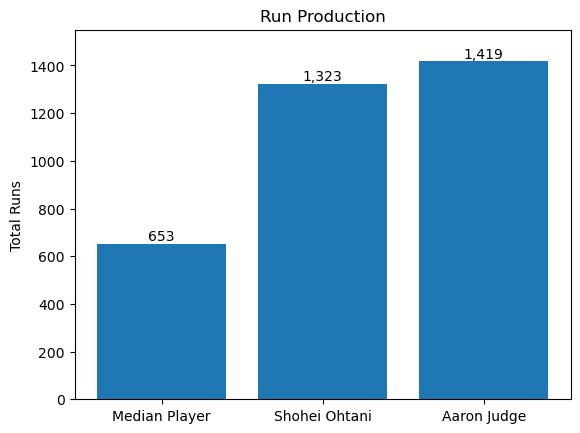

In [247]:
# Bar Plot 
import matplotlib.pyplot as plt

player_names = ['Median Player', 'Shohei Ohtani', 'Aaron Judge']
runs = [653, 1323, 1419]

fig, ax = plt.subplots()
bar_container = ax.bar(player_names, runs)
ax.set(ylabel='Total Runs', title='Run Production', ylim=(0, 1550))
ax.bar_label(bar_container, fmt='{:,.0f}')
plt.show()

Conclusion:
This project analyzed the run production of Aaron Judge, Shohei Ohtani, and an imagined median player representing a typical MLB career statline using a Markov Chain model to simulate 10,000 at-bats for each player. The results showcase the significant contributions of Judge and Ohtani compared to this benchmark.

Over 10,000 simulations, Aaron Judge scored a total of 1,419 runs, averaging 0.142 runs per simulation, which is approximately 117.3% better than the imagined median player.
Shohei Ohtani scored a total of 1,323 runs, averaging 0.132 runs per simulation, making him approximately 102.6% better than the imagined median player.
The imagined median player, representing a typical MLB career statline, scored a total of 653 runs, averaging 0.065 runs per simulation.
The difference in performance between Aaron Judge and Shohei Ohtani can largely be attributed to their probabilities of hitting home runs during an at-bat:

Aaron Judge has an 8.27% chance of hitting a home run during an at-bat.
Shohei Ohtani has a 6.76% chance, which is 2% lower than Judge's probability.
This slight edge in home run probability translates to more runs scored for Aaron Judge, as home runs have a greater impact on run production than other types of hits. Judge's ability to generate runs through power hitting demonstrates his exceptional offensive efficiency.

These findings highlight the effectiveness of Markov Chain modeling in quantifying player performance and provide actionable insights into the unique strengths of two of baseball's most impactful players, compared to a typical MLB baseline